# Rochesso's QFDN vs Quantum Sensing — Head-to-Head Comparison

**Goal**: Compare Rochesso's Quantum Feedback Delay Network (QFDN) with our NV-center
quantum sensing dual-channel mode on equal footing.

**Four tests**:
1. **Impulse Response** — spectral fingerprint of each system  
2. **Damped Sinusoid** — how each system colours a decaying tone  
3. **Base Notes** — discrete notes (0.1 s on / 0.2 s silence, 1 s total)  
4. **Audio File** — real-world audio processing + listening comparison

**QFDN reimplementation**: Rochesso's algorithm is reproduced here using pure numpy
(no Qiskit dependency). Verification code at the bottom lets you confirm identical
outputs inside Rochesso's original notebook.

## Parameters

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import soundfile
from scipy.signal import resample
from IPython.display import Audio, display
import os, sys
from quantum_audio_master import trotterize_sensing_dual, trotterize_sensing
%matplotlib inline
plt.rcParams['figure.dpi'] = 100

FS = 8000
SWAP_IN, SWAP_OUT = 0.9, 0.9
PHASE_SCALE = 0.5
XX_COUPLING = 0.3              # sensing joint coupling is ALWAYS xx
FB_ANGLE    = 1.0              # exp_feed_back swap angle
QFDN_FCOEF  = 0.61             # Rochesso feedback: pulled DOWN from 0.99 so the tail decays
# Rocchesso Fig 2.4 feedback matrix: G = Z·R_Y(theta) (theta=-pi/2 -> Hadamard).
# 2-qubit QFDN matrix = G (x) G.  theta=-pi/16 is his explicit intermediate-decay example.
QFDN_FB_THETA = -np.pi/16
def _qfdn_combgate(theta):
    Z  = np.array([[1.0,0.0],[0.0,-1.0]])
    RY = np.array([[np.cos(theta/2), -np.sin(theta/2)],[np.sin(theta/2), np.cos(theta/2)]])
    G  = Z @ RY
    return np.kron(G, G)
QFDN_FB_MATRIX = _qfdn_combgate(QFDN_FB_THETA)   # set to None to use the default Householder

# ── delay alignment (single vs dual) ───────────────────────────────
SINGLE_D           = 7               # single-channel sensing delay
QFDN_SINGLE_DELAYS = (7, 11)           # Rochesso 2-delay, matched to single
D1, D2             = 2, 3             # dual-channel sensing delays
QFDN_DUAL_DELAYS   = (2, 3, 5, 6)     # Rochesso 4-delay, matched to dual

# ── signal lengths ─────────────────────────────────────────────────
SIN_F0, SIN_TAU, SIN_SEC = 50.0, 0.8, 3.0     # damped sinusoid (~3 s)
NOTE_FREQS = [65.41, 82.41, 98.00]            # C2 E2 G2   <- change pitches here
NOTE_DUR   = 0.20                              # s per note (2x longer)
SIL_DUR    = 0.60                              # s silence (3x longer)
AUDIO_PATH = 'audio/windchimes.wav'               # <- change input sound here
AUDIO_SEC  = 7.0                               # truncate audio input
START_S    = 48.0                               # start offset into the file (seconds)
ONSET_MS   = 40.0                              # onset window ignored when matching FB output to input
FADE_MS    = 40.0                              # onset fade (ms): omit the nasty warmup beginning
print('params loaded')

params loaded


## Rochesso's QFDN Engine (using Qiskit)

Two QFDN variants are provided:

1. **`run_qfdn_amplitude`** — Cell 21 of `QFDN.ipynb`: 4 amplitude delay lines + CNOT input.
   The most complete QFDN with quantum input coupling via partial trace.

2. **`run_qfdn_marginal`** — Cell 15 of `QFDN.ipynb`: 2 marginal-probability delay lines + 
   sum-normalize input. The canonical QFDN with classical input mixing.

Both use the Householder maximally-diffusive matrix $A = \frac{1}{2}\begin{pmatrix}-1&1&1&1\\1&-1&1&1\\1&1&-1&1\\1&1&1&-1\end{pmatrix}$

All quantum operations use Qiskit directly — identical to Rochesso's original code.

In [2]:
# ============================================================
# Rochesso's QFDN — using Qiskit (same as original notebook)
# ============================================================
from qiskit import QuantumCircuit
from qiskit.circuit.library import UnitaryGate
from qiskit.quantum_info import Statevector, partial_trace

# ── CircularBuffer (verbatim from Rochesso) ──────────────────
class CircularBuffer:
    """class that implements a circular buffer"""
    def __init__(self, size_max, init_value):
        self.max = size_max
        self.data = np.zeros(self.max, dtype='complex_') + init_value
        self.cur = 0
    def put(self, x):
        """write an element overwriting the oldest one."""
        self.data[self.cur] = x
        self.cur = (self.cur + 1) % self.max
    def get(self):
        """return element at cur"""
        return self.data[self.cur]


# ── Householder matrix (Rochesso Eq. 2.3) ────────────────────
HOUSEHOLDER = [[-.5, .5, .5, .5],
               [.5, -.5, .5, .5],
               [.5, .5, -.5, .5],
               [.5, .5, .5, -.5]]


# ════════════════════════════════════════════════════════════════
# Variant 1 — 4 amplitude delay lines + CNOT input  (Cell 21)
# ════════════════════════════════════════════════════════════════
def run_qfdn_amplitude(input_signal, fs=8000,
                       delay_lengths=(23, 29, 51, 73),
                       fCoef=0.99, matrix=None):
    """
    Rochesso QFDN: 4 amplitude delay lines, CNOT input coupling.
    Processing loop is verbatim Cell 21 of QFDN.ipynb.
    
    Parameters
    ----------
    input_signal : 1-D array, values in [-1, 1].
    fs           : sample rate (Hz).
    delay_lengths: tuple of 4 ints — circular buffer lengths.
    fCoef        : feedback coefficient on delay line 0.
    matrix       : 4x4 unitary (default Householder).
    
    Returns  dict with 'output', 'output_raw', 'fs', 'tlist'.
    """
    Matrix = HOUSEHOLDER if matrix is None else matrix
    FDNgate = UnitaryGate(Matrix)
    FDN = QuantumCircuit(3, 2)
    FDN.append(FDNgate, [0, 1])
    FDN.cx(2, 0)
    
    # Convert input from [-1,1] to [0,1] QPAM encoding
    qpam = np.clip(input_signal * 0.5 + 0.5, 0.0, 1.0)
    N = len(qpam)
    m0, m1, m2, m3 = delay_lengths
    initDelays = 0.5
    
    delay = [CircularBuffer(m0, initDelays), CircularBuffer(m1, initDelays),
             CircularBuffer(m2, initDelays), CircularBuffer(m3, initDelays)]
    stateIn  = np.zeros(4, dtype=complex) + 0.5
    stateOut = np.zeros(4, dtype=complex) + 0.5
    output = np.zeros(N)
    
    # ── Processing loop (verbatim Cell 21) ────────────────────
    for n in range(N):
        ssq = np.sqrt(np.abs(delay[0].get()*fCoef)**2 +
                      np.abs(delay[1].get())**2 +
                      np.abs(delay[2].get())**2 +
                      np.abs(delay[3].get())**2)
        stateOut[0] = delay[0].get()*fCoef / ssq
        stateOut[1] = delay[1].get()       / ssq
        stateOut[2] = delay[2].get()       / ssq
        stateOut[3] = delay[3].get()       / ssq
        delay[0].put(stateIn[0])
        delay[1].put(stateIn[1])
        delay[2].put(stateIn[2])
        delay[3].put(stateIn[3])
        sOut = Statevector(stateOut)
        output[n] = np.sqrt(sOut.probabilities([0])[0])
        sIn = Statevector([np.sqrt((1 - qpam[n]**2)), qpam[n]])
        sOutIn = sOut.tensor(sIn)
        sOutIn = sOutIn.evolve(FDN)
        partial_density_matrix = partial_trace(sOutIn, [2])
        stateIn = np.diagonal(partial_density_matrix)
        stateIn = stateIn / np.sqrt(np.sum(np.square(stateIn)))
    
    return dict(output=output - np.mean(output), output_raw=output,
                fs=fs, tlist=np.arange(N)/fs,
                delay_lengths=delay_lengths, fCoef=fCoef,
                label='QFDN-amp (Cell 21)')


# ════════════════════════════════════════════════════════════════
# Variant 2 — 2 marginal-probability delays + sum-norm  (Cell 15)
# ════════════════════════════════════════════════════════════════
def run_qfdn_marginal(input_signal, fs=8000,
                      delay_lengths=(29, 37),
                      fCoef=0.99, matrix=None):
    """
    Rochesso QFDN: 2 marginal-probability delay lines, sum-normalise input.
    Processing loop is verbatim Cell 15 of QFDN.ipynb.
    
    Parameters
    ----------
    input_signal : 1-D array, values in [-1, 1].
    fs           : sample rate (Hz).
    delay_lengths: tuple of 2 ints — circular buffer lengths.
    fCoef        : feedback coefficient.
    matrix       : 4x4 unitary (default Householder).
    
    Returns  dict with 'output', 'output_raw', 'fs', 'tlist'.
    """
    Matrix = HOUSEHOLDER if matrix is None else matrix
    FDNgate = UnitaryGate(Matrix)
    FDN_circ = QuantumCircuit(2, 2)
    FDN_circ.append(FDNgate, [0, 1])
    
    # Convert input from [-1,1] to [0,1] QPAM encoding
    qpam = np.clip(input_signal * 0.5 + 0.5, 0.0, 1.0)
    N = len(qpam)
    m1, m2 = delay_lengths
    initDelay = 0.5
    
    delay = [CircularBuffer(m1, initDelay), CircularBuffer(m2, initDelay)]
    stateIn  = np.zeros(4) + 0.5
    stateOut = np.zeros(4) + 0.5
    output = np.zeros(N)
    
    # ── Processing loop (verbatim Cell 15) ────────────────────
    for n in range(N):
        aq = min(delay[0].get(), delay[1].get())
        stateOut[0] = np.sqrt(aq) * fCoef
        stateOut[1] = np.sqrt(delay[1].get() - aq)
        stateOut[2] = np.sqrt(delay[0].get() - aq)
        stateOut[3] = np.sqrt(1 - np.abs(stateOut[0])**2 -
                              np.abs(stateOut[1])**2 -
                              np.abs(stateOut[2])**2)
        # input of delays are marginal probabilities
        delay[0].put(np.abs(np.diagonal(
            partial_trace(Statevector(stateIn), [1]))[0]))
        delay[1].put(np.abs(np.diagonal(
            partial_trace(Statevector(stateIn), [0]))[0]))
        sOut = Statevector(stateOut)
        output[n] = np.sqrt(sOut.probabilities([0])[0])
        sOut = sOut.evolve(FDN_circ)
        stateOut = sOut.data
        sIn = Statevector([qpam[n],
                           np.sqrt((1 - qpam[n]**2)/3),
                           np.sqrt((1 - qpam[n]**2)/3),
                           np.sqrt((1 - qpam[n]**2)/3)])
        stateIn[0] = np.sqrt((np.abs(sIn[0])**2 + np.abs(stateOut[0])**2)/2)
        stateIn[1] = np.sqrt((np.abs(sIn[1])**2 + np.abs(stateOut[1])**2)/2)
        stateIn[2] = np.sqrt((np.abs(sIn[2])**2 + np.abs(stateOut[2])**2)/2)
        stateIn[3] = np.sqrt((np.abs(sIn[3])**2 + np.abs(stateOut[3])**2)/2)
    
    return dict(output=output - np.mean(output), output_raw=output,
                fs=fs, tlist=np.arange(N)/fs,
                delay_lengths=delay_lengths, fCoef=fCoef,
                label='QFDN-marg (Cell 15)')

print("QFDN engine loaded (Qiskit): run_qfdn_amplitude(), run_qfdn_marginal()")

QFDN engine loaded (Qiskit): run_qfdn_amplitude(), run_qfdn_marginal()


## Sensing helpers (run_sensing dual, compare_plot, signal generators)

In [3]:
# ============================================================
# Test signal generators + comparison plotting
# ============================================================

def make_impulse(duration, fs):
    """Unit impulse at t=0."""
    n = int(duration * fs)
    x = np.zeros(n)
    x[0] = 1.0
    return x, np.arange(n) / fs

def make_damped_sinusoid(f0, tau, duration, fs):
    """Exponentially damped sinusoid: sin(2πf0·t)·exp(-t/τ)."""
    n = int(duration * fs)
    t = np.arange(n) / fs
    x = np.sin(2 * np.pi * f0 * t) * np.exp(-t / tau)
    return x, t

def make_base_notes(freqs, note_dur=0.1, silence_dur=0.2, fs=500):
    """
    Discrete bass notes with silence between them.
    Total ≈ len(freqs)*note_dur + (len(freqs)-1)*silence_dur + trailing silence → ~1 s.
    """
    segments = []
    for i, f in enumerate(freqs):
        n_note = int(note_dur * fs)
        t_note = np.arange(n_note) / fs
        env = 0.5 * (1 - np.cos(2 * np.pi * t_note / note_dur))
        segments.append(np.sin(2 * np.pi * f * t_note) * env)
        if i < len(freqs) - 1:
            segments.append(np.zeros(int(silence_dur * fs)))
    x = np.concatenate(segments)
    target_len = max(int(1.0 * fs), len(x))
    if len(x) < target_len:
        x = np.concatenate([x, np.zeros(target_len - len(x))])
    return x[:target_len], np.arange(len(x[:target_len])) / fs


def run_sensing(signal, sens_rate, d1=None, d2=None, joint_mode='xx',
                exp_feed_back=False, feedback_swap_angle=None):
    """DUAL sensing. d1,d2 are tweakable (default globals D1,D2)."""
    d1 = D1 if d1 is None else d1
    d2 = D2 if d2 is None else d2
    fa = FB_ANGLE if feedback_swap_angle is None else feedback_swap_angle
    t_seq = 1.0 / sens_rate
    res = trotterize_sensing_dual(
        signal, sens_rate, 0.8*t_seq, t_seq, phase_scale=PHASE_SCALE,
        delay1=d1, delay2=d2, swap_angle_in=SWAP_IN, swap_angle_out=SWAP_OUT,
        joint_mode=joint_mode, xx_coupling=XX_COUPLING,
        exp_feed_back=exp_feed_back, feedback_swap_angle=fa,
        summation_mode='rms', verbose=False)
    out = res['output_combined'] - np.mean(res['output_combined'])
    tag = ' +FB' if exp_feed_back else ''
    return dict(output=out, fs=sens_rate, tlist=res['tlist'],
                ch1=res['ch1_sz'], ch2=res['ch2_sz'],
                label=f'Dual d={d1},{d2} ({joint_mode}){tag}', raw_result=res)


def compare_plot(results, title, input_signal=None, input_fs=None):
    """
    Side-by-side comparison with SHARED y-axis scales.
    No auto-scaling tricks — honest amplitude comparison.
    """
    n = len(results)
    fig, axes = plt.subplots(2, n, figsize=(5*n, 7), squeeze=False)
    fig.suptitle(title, fontsize=14, fontweight='bold')
    
    # Find global y-limits for honest comparison
    all_y = [r['output'] for r in results]
    y_max = max(np.max(np.abs(y)) for y in all_y) * 1.1
    if y_max < 1e-10:
        y_max = 1.0
    
    # Find global dB limits for spectra
    all_mags = []
    for r in results:
        y = r['output']; fs = r['fs']
        nfft = min(len(y), 4096)
        Y = np.fft.rfft(y, n=nfft)
        all_mags.append(20 * np.log10(np.abs(Y) + 1e-12))
    db_max = max(np.max(m) for m in all_mags) + 5
    db_min = db_max - 80
    
    for col, r in enumerate(results):
        t = r['tlist']
        y = r['output']
        fs = r['fs']
        label = r.get('label', f'System {col}')
        peak = np.max(np.abs(y))
        
        # time domain — shared y-axis
        ax = axes[0, col]
        if input_signal is not None and col == 0:
            t_in = np.arange(len(input_signal)) / input_fs
            ax.plot(t_in, input_signal, 'k-', alpha=0.3, label='input')
        ax.plot(t, y, linewidth=0.8, label=label)
        ax.set_title(f'{label}\npeak = {peak:.4f}')
        ax.set_xlabel('Time (s)')
        ax.set_ylabel('Amplitude')
        ax.set_ylim(-y_max, y_max)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        
        # spectrum — shared dB axis
        ax = axes[1, col]
        nfft = min(len(y), 4096)
        Y = np.fft.rfft(y, n=nfft)
        freqs = np.fft.rfftfreq(nfft, 1/fs)
        mag = 20 * np.log10(np.abs(Y) + 1e-12)
        ax.plot(freqs, mag, linewidth=0.7)
        ax.set_title(f'{label} — Spectrum')
        ax.set_xlabel('Frequency (Hz)')
        ax.set_ylabel('Magnitude (dB)')
        ax.set_xlim(0, fs/2)
        ax.set_ylim(db_min, db_max)
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def make_audio_for_all(results, target_sr=44100):
    """Resample all results to target_sr and play them inline."""
    for r in results:
        y = r['output']
        fs = r['fs']
        n_out = int(len(y) * target_sr / fs)
        y_rs = resample(y, max(n_out, 2))
        peak = np.max(np.abs(y_rs))
        if peak > 0:
            y_rs = y_rs / peak * 0.8
        label = r.get('label', 'output')
        print(f"  {label}  (native {fs} Hz → {target_sr} Hz, {len(y_rs)} samples)")
        display(Audio(y_rs, rate=target_sr))

print("Helpers loaded.")

Helpers loaded.


## Single-channel sensing + amplitude stretch

In [4]:
# ── Single-channel sensing + amplitude stretch (items 1, 3, 5) ─────────────
# Single sensing is the apples-to-apples match for the 2-delay QFDN (one system
# qubit, no joint mode). It also allows a longer delay line than dual (d up to ~9).
from quantum_audio_master import trotterize_sensing

def _peak(y): y = y - np.mean(y); return float(np.max(np.abs(y)))

def run_single_raw(sig, swap_out=None, exp_fb=False, fb_angle=None, delay=None):
    delay = SINGLE_D if delay is None else delay
    so = SWAP_OUT if swap_out is None else swap_out
    fa = FB_ANGLE if fb_angle is None else fb_angle
    t = 1.0/FS
    kw = dict(exp_feed_back=True, feedback_swap_angle=fa) if exp_fb else {}
    o = trotterize_sensing(sig, FS, 0.8*t, t, phase_scale=PHASE_SCALE, delay=delay,
            swap_angle_in=SWAP_IN, swap_angle_out=so, method='sin_phi', **kw)['aux_sigma_z']
    return o - np.mean(o)

_REF_GAIN = None
def calibrate_stretch_gain(delay=None):
    """Empirical impulse calibration: peak(unattenuated swap_out=0)/peak(real swap_out)."""
    N=int(0.3*FS); imp=np.zeros(N); imp[0]=1.0
    return _peak(run_single_raw(imp, swap_out=0.0, delay=delay)) / (
           _peak(run_single_raw(imp, swap_out=SWAP_OUT, delay=delay)) + 1e-12)

def apply_stretch(out, method='empirical', ceiling=0.99):
    """Stretch the STANDARD read, then global down-scale if peak>ceiling (no clipping).
       method='analytic' -> 1/cos^2(SWAP_OUT);  'empirical' -> calibrated gain."""
    global _REF_GAIN
    if method=='analytic':   gain = 1.0/np.cos(SWAP_OUT)**2
    elif method=='empirical':
        if _REF_GAIN is None: _REF_GAIN = calibrate_stretch_gain()
        gain = _REF_GAIN
    else: raise ValueError("method must be 'analytic' or 'empirical'")
    y = out*gain; pk = float(np.max(np.abs(y)))
    if pk > ceiling: y = y*(ceiling/pk)        # anti-clip: global, preserves shape
    return y

def run_single(sig, delay=None, stretch=None, exp_fb=False, fb_angle=None):
    """SINGLE-channel sensing. stretch in {None,'analytic','empirical'} (standard read only)."""
    delay = SINGLE_D if delay is None else delay
    out = run_single_raw(sig, exp_fb=exp_fb, fb_angle=fb_angle, delay=delay)
    lab = f'Single d={delay}'
    if exp_fb: lab += ' +FB'
    elif stretch: out = apply_stretch(out, stretch); lab += f' [{stretch}]'
    return dict(output=out, fs=FS, tlist=np.arange(len(out))/FS, label=lab)

print('single sensing + stretch loaded: run_single(), apply_stretch(), calibrate_stretch_gain()')

single sensing + stretch loaded: run_single(), apply_stretch(), calibrate_stretch_gain()


## Post-processing + presentation helper

In [5]:
# ── Post-processing + presentation (util) ─────────────────────────────────
from scipy.signal import butter, filtfilt

def dc_filter(y, cutoff_hz=15.0, order=4):
    """Zero-phase high-pass: removes DC / near-0 freqs -> kills start/end clicks (Rocchesso)."""
    b, a = butter(order, cutoff_hz/(FS/2.0), btype='high'); return filtfilt(b, a, y)

def fade_edges(y, fade_in_ms=None, fade_out_ms=15.0):
    """Raised-cosine fade at the START (removes the warmup onset so it stops
    dominating the gain/normalisation) + short fade at the END (kills trailing
    click). The body is untouched -> normalisation now keys off the body."""
    y = np.asarray(y, dtype=float).copy()
    fi = FADE_MS if fade_in_ms is None else fade_in_ms
    ni = int(fi*FS/1000.0); no = int(fade_out_ms*FS/1000.0)
    if 0 < ni < len(y): y[:ni]  *= 0.5*(1-np.cos(np.linspace(0, np.pi, ni)))
    if 0 < no < len(y): y[-no:] *= 0.5*(1+np.cos(np.linspace(0, np.pi, no)))
    return y

def _peak(y): y = y - np.mean(y); return float(np.max(np.abs(y)))

def apply_gain_clip(y, gain, ceiling=0.99):
    z = y*gain; pk = float(np.max(np.abs(z)))
    return z*(ceiling/pk) if pk > ceiling else z

def amplify_to_input(y, inp, exclude_onset_ms=ONSET_MS, ceiling=0.99):
    """Max-match to input, measured on the BODY (ignoring the loud onset that is
    never reproduced); global anti-clip keeps the onset <= ceiling."""
    n0 = int(exclude_onset_ms*FS/1000.0); body = y[n0:] if 0 < n0 < len(y) else y
    g = np.max(np.abs(inp)) / (np.max(np.abs(body)) + 1e-12)
    return apply_gain_clip(y, g, ceiling)

# empirical stretch gain for the STANDARD read (impulse calibration; single~dual within ~2%)
def _calib_stretch():
    N=int(0.3*FS); imp=np.zeros(N); imp[0]=1.0
    return _peak(dc_filter(run_single_raw(imp, swap_out=0.0))) / (
           _peak(dc_filter(run_single_raw(imp, swap_out=SWAP_OUT))) + 1e-12)
STRETCH_GAIN = _calib_stretch()
print(f'empirical stretch gain (standard read) = {STRETCH_GAIN:.3f}')

RAW_SENSING = {}   # collects every raw sensing run for the final summary

def run_and_present(name, inp, mode, play=True):
    """mode in {'single','dual'}. QFDN (matched delays) vs sensing std+FB.
    EVERYTHING shown/played is DC-filtered (kills start/end clicks) and soft
    peak-limited (no hard clipping). standard read -> DC + empirical stretch ;
    FB read -> DC + max-matched to the (DC-filtered) input."""
    if mode == 'single':
        qf  = run_qfdn_marginal(inp, delay_lengths=QFDN_SINGLE_DELAYS, fCoef=QFDN_FCOEF, matrix=QFDN_FB_MATRIX)['output']
        std = run_single_raw(inp)                       # exp value AFTER swap
        fbv = run_single_raw(inp, exp_fb=True)          # exp value BEFORE swap
        qlab=f'QFDN 2-delay {QFDN_SINGLE_DELAYS}'; slab=f'single d={SINGLE_D}'
    else:
        qf  = run_qfdn_amplitude(inp, delay_lengths=QFDN_DUAL_DELAYS, fCoef=QFDN_FCOEF, matrix=QFDN_FB_MATRIX)['output']
        std = run_sensing(inp, FS, d1=D1, d2=D2, joint_mode='xx')['output']
        fbv = run_sensing(inp, FS, d1=D1, d2=D2, joint_mode='xx', exp_feed_back=True)['output']
        qlab=f'QFDN 4-delay {QFDN_DUAL_DELAYS}'; slab=f'dual ({D1},{D2})'
    RAW_SENSING[f'{name} / {slab} std'] = std   # store RAW (unfiltered) for the summary
    RAW_SENSING[f'{name} / {slab} fb']  = fbv
    # ── DC-filter ALL traces (input + QFDN + sensing) for an apples-to-apples,
    #    click-free comparison of 'what went in' vs 'what came out' ──
    fin = 3.0 if 'Impulse' in name else FADE_MS   # short fade for the IR; full fade omits warmup onset
    _flt = lambda y: fade_edges(dc_filter(y), fin)
    inp_f = _flt(inp)
    qf_f  = _flt(qf)
    std_p = apply_gain_clip(_flt(std), STRETCH_GAIN)   # standard: empirical stretch (onset faded)
    fb_p  = amplify_to_input(_flt(fbv), inp_f)         # FB: max-matched to input body
    sigs = [('input [dc]', inp_f, 'k'), (qlab+' [dc]', qf_f, 'tab:blue'),
            (slab+' std  [dc+stretch]', std_p, 'tab:orange'),
            (slab+' FB  [dc+match]',    fb_p,  'tab:green')]
    fig, ax = plt.subplots(1, 4, figsize=(19, 3.2))
    fig.suptitle(f'{name}  —  {mode}', fontweight='bold')
    for a,(lab,y,col) in zip(ax, sigs):
        a.plot(np.arange(len(y))/FS, y, col, lw=0.7); a.set_title(lab, fontsize=8)
        a.grid(alpha=.3); a.axhline(0,color='k',lw=.3); a.set_xlabel('s')
    plt.tight_layout(); plt.show()
    if play:
        for lab,y,_ in sigs:
            yr = resample(y, int(len(y)*44100/FS))
            yr = apply_gain_clip(yr, 1.0)            # soft global limit to <=0.99 (NO hard clip)
            print(f'  {lab}   (peak {np.max(np.abs(yr)):.3f})'); display(Audio(yr, rate=44100))


empirical stretch gain (standard read) = 1.415


# Runs

8 run cells: {Impulse, Sinusoid 3 s, Bass, Audio} × {single, dual}. Each shows input, matched Rocchesso QFDN, sensing **standard** (DC+empirical stretch), sensing **+FB** (DC+max-matched to input).

### Run 1 — Impulse (IR) · single

In [6]:
# ── Run 1: Impulse (IR) — single sensing vs matched QFDN ──
ir = np.zeros(int(0.6*FS)); ir[0]=1.0
run_and_present('Impulse (IR)', ir, 'single')

KeyboardInterrupt: 

### Run 2 — Impulse (IR) · dual

In [ ]:
# ── Run 2: Impulse (IR) — dual sensing vs matched QFDN ──
run_and_present('Impulse (IR)', ir, 'dual')

### Run 3 — Sinusoid 3s · single

In [ ]:
# ── Run 3: Sinusoid 3s — single sensing vs matched QFDN ──
sin3, _ = make_damped_sinusoid(SIN_F0, SIN_TAU, SIN_SEC, FS)
run_and_present('Sinusoid 3s', sin3, 'single')

### Run 4 — Sinusoid 3s · dual

In [ ]:
# ── Run 4: Sinusoid 3s — dual sensing vs matched QFDN ──
run_and_present('Sinusoid 3s', sin3, 'dual')

### Run 5 — Bass notes · single

In [ ]:
# ── Run 5: Bass notes — single sensing vs matched QFDN ──
bass = make_base_notes(NOTE_FREQS, NOTE_DUR, SIL_DUR, fs=FS)[0]
run_and_present('Bass notes', bass, 'single')

### Run 6 — Bass notes · dual

In [ ]:
# ── Run 6: Bass notes — dual sensing vs matched QFDN ──
run_and_present('Bass notes', bass, 'dual')

### Run 7 — Audio input · single

audio/windchimes.wav: 7.0s @ 8000Hz


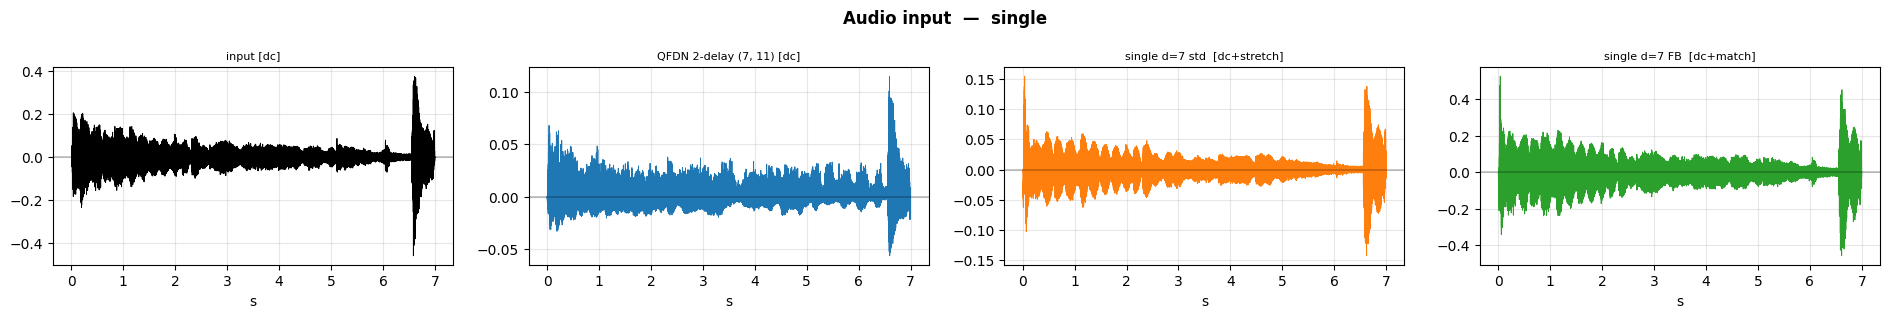

  input [dc]   (peak 0.481)


  QFDN 2-delay (7, 11) [dc]   (peak 0.117)


  single d=7 std  [dc+stretch]   (peak 0.157)


  single d=7 FB  [dc+match]   (peak 0.530)


In [7]:
# ── Run 7: Audio input — single sensing vs matched QFDN ──
d,sr=soundfile.read(AUDIO_PATH)
if d.ndim>1: d=d[:,0]
d=d/(np.max(np.abs(d))+1e-12)
audio_in=resample(d,int(len(d)*FS/sr))[int(START_S*FS):int((START_S+AUDIO_SEC)*FS)]
print(f'{AUDIO_PATH}: {len(audio_in)/FS:.1f}s @ {FS}Hz')
run_and_present('Audio input', audio_in, 'single')

### Run 8 — Audio input · dual

In [ ]:
# ── Run 8: Audio input — dual sensing vs matched QFDN ──
run_and_present('Audio input', audio_in, 'dual')

# Summary — raw output of all 16 sensing runs

In [ ]:
# ── Summary: RAW (unprocessed) output of all 16 sensing runs ──────────────
items = list(RAW_SENSING.items())
print(f'{len(items)} sensing runs collected')
ncol=4; nrow=int(np.ceil(len(items)/ncol))
fig, ax = plt.subplots(nrow, ncol, figsize=(18, 2.7*nrow), squeeze=False)
for k,(lab,y) in enumerate(items):
    a=ax[k//ncol][k%ncol]; a.plot(np.arange(len(y))/FS, y-np.mean(y), lw=0.6)
    a.set_title(lab, fontsize=8); a.grid(alpha=.3); a.set_xlabel('s')
for k in range(len(items), nrow*ncol): ax[k//ncol][k%ncol].axis('off')
plt.tight_layout(); plt.show()

In [ ]:
# IR (impulse) of the 4 sensing modes: single std/FB (top), dual std/FB (bottom)
import matplotlib.pyplot as plt
RUN = 'Impulse (IR)'
def _fade(y, fin, fout=15.0):
    y = np.asarray(y, float).copy(); ni=int(fin*FS/1000); no=int(fout*FS/1000)
    if 0<ni<len(y): y[:ni]*=0.5*(1-np.cos(np.linspace(0,np.pi,ni)))
    if 0<no<len(y): y[-no:]*=0.5*(1+np.cos(np.linspace(0,np.pi,no)))
    return y
def _proc(y, fin=3.0):                       # short fade for the IR; dc + normalise
    z=_fade(dc_filter(np.asarray(y,float)), fin); return z/(np.max(np.abs(z))+1e-12)*0.9
def _sens(mode, kind):
    slab = f'single d={SINGLE_D}' if mode=='single' else f'dual ({D1},{D2})'
    return RAW_SENSING.get(f'{RUN} / {slab} {kind}')
panels = [(f'single d={SINGLE_D}  post-measure', 'single','std'), (f'single d={SINGLE_D}  pre-measure', 'single','fb'),
          (f'dual ({D1},{D2})  post-measure', 'dual','std'),       (f'dual ({D1},{D2})  pre-measure', 'dual','fb')]
fig, ax = plt.subplots(2, 2, figsize=(11, 6)); fig.suptitle('Impulse response — 4 sensing modes', fontweight='bold')
for a,(title,m,k) in zip(ax.flat, panels):
    y=_sens(m,k)
    if y is None: a.set_title(title+'  (run Run 1/2 first)', fontsize=8); a.axis('off'); continue
    p=_proc(y); a.plot(np.arange(len(p))/FS, p, lw=0.7); a.set_title(title, fontsize=9)
    a.grid(alpha=.3); a.set_xlabel('s'); a.set_ylim(-1,1)
plt.tight_layout(); plt.show()

In [ ]:
# rows: original, Rocchesso (2-delay), single std, single FB ; cols: bass, audio
import matplotlib.pyplot as plt
def _fade(y, fin=40.0, fout=15.0):
    y=np.asarray(y,float).copy(); ni=int(fin*FS/1000); no=int(fout*FS/1000)
    if 0<ni<len(y): y[:ni]*=0.5*(1-np.cos(np.linspace(0,np.pi,ni)))
    if 0<no<len(y): y[-no:]*=0.5*(1+np.cos(np.linspace(0,np.pi,no)))
    return y
def _proc(y): z=_fade(dc_filter(np.asarray(y,float))); return z/(np.max(np.abs(z))+1e-12)*0.9
def _inp(run, var):
    y=globals().get(var)
    if y is not None: return y
    if run=='Bass notes':  return make_base_notes(NOTE_FREQS, NOTE_DUR, SIL_DUR, fs=FS)[0]
    d,sr=soundfile.read(AUDIO_PATH); d=d[:,0] if d.ndim>1 else d
    return resample(d/(np.max(np.abs(d))+1e-12), int(len(d)*FS/sr))[int(START_S*FS):int((START_S+AUDIO_SEC)*FS)]
def _sens(run, kind):
    return RAW_SENSING.get(f'{run} / single d={SINGLE_D} {kind}')
COLS=[('Bass notes','bass'),('Audio input','audio_in')]; M=globals().get('QFDN_FB_MATRIX',None)
ROWlab=['original','Rocchesso (2-delay)',f'single d={SINGLE_D} std',f'single d={SINGLE_D} FB']
fig,ax=plt.subplots(4,2,figsize=(12,9)); fig.suptitle('Original · Rocchesso · single std · single FB', fontweight='bold')
for c,(run,var) in enumerate(COLS):
    inp=_inp(run,var)
    qf=run_qfdn_marginal(inp, delay_lengths=QFDN_SINGLE_DELAYS, fCoef=QFDN_FCOEF, matrix=M)['output']
    rows=[inp, qf, _sens(run,'std'), _sens(run,'fb')]
    for r,y in enumerate(rows):
        a=ax[r][c]
        if y is None: a.set_title(f'{run}: {ROWlab[r]} (run that cell)', fontsize=7); a.axis('off'); continue
        p=_proc(y); a.plot(np.arange(len(p))/FS, p, lw=0.6); a.grid(alpha=.3); a.set_ylim(-1,1)
        a.set_title(f'{run.split()[0]} — {ROWlab[r]}', fontsize=8)
        if r==3: a.set_xlabel('s')
plt.tight_layout(); plt.show()

In [ ]:
# rows: original, Rocchesso (2-delay), single std, single FB ; cols: bass, audio
import matplotlib.pyplot as plt
def _fade(y, fin=40.0, fout=15.0):
    y=np.asarray(y,float).copy(); ni=int(fin*FS/1000); no=int(fout*FS/1000)
    if 0<ni<len(y): y[:ni]*=0.5*(1-np.cos(np.linspace(0,np.pi,ni)))
    if 0<no<len(y): y[-no:]*=0.5*(1+np.cos(np.linspace(0,np.pi,no)))
    return y
def _proc(y): z=_fade(dc_filter(np.asarray(y,float))); return z/(np.max(np.abs(z))+1e-12)*0.9
def _inp(run, var):
    y=globals().get(var)
    if y is not None: return y
    if run=='Bass notes':  return make_base_notes(NOTE_FREQS, NOTE_DUR, SIL_DUR, fs=FS)[0]
    d,sr=soundfile.read(AUDIO_PATH); d=d[:,0] if d.ndim>1 else d
    return resample(d/(np.max(np.abs(d))+1e-12), int(len(d)*FS/sr))[int(START_S*FS):int((START_S+AUDIO_SEC)*FS)]
def _sens(run, kind):
    return RAW_SENSING.get(f'{run} / single d={SINGLE_D} {kind}')
COLS=[('Bass notes','bass'),('Audio input','audio_in')]; M=globals().get('QFDN_FB_MATRIX',None)
ROWlab=['original','Rocchesso (2-delay)',f'single d={SINGLE_D} std',f'single d={SINGLE_D} FB']
fig,ax=plt.subplots(4,2,figsize=(12,9)); fig.suptitle('Original · Rocchesso · single std · single FB', fontweight='bold')
for c,(run,var) in enumerate(COLS):
    inp=_inp(run,var)
    qf=run_qfdn_marginal(inp, delay_lengths=QFDN_SINGLE_DELAYS, fCoef=QFDN_FCOEF, matrix=M)['output']
    rows=[inp, qf, _sens(run,'std'), _sens(run,'fb')]
    for r,y in enumerate(rows):
        a=ax[r][c]
        if y is None: a.set_title(f'{run}: {ROWlab[r]} (run that cell)', fontsize=7); a.axis('off'); continue
        p=_proc(y); a.plot(np.arange(len(p))/FS, p, lw=0.6); a.grid(alpha=.3); a.set_ylim(-1,1)
        a.set_title(f'{run.split()[0]} — {ROWlab[r]}', fontsize=8)
        if r==3: a.set_xlabel('s')
plt.tight_layout(); plt.show()

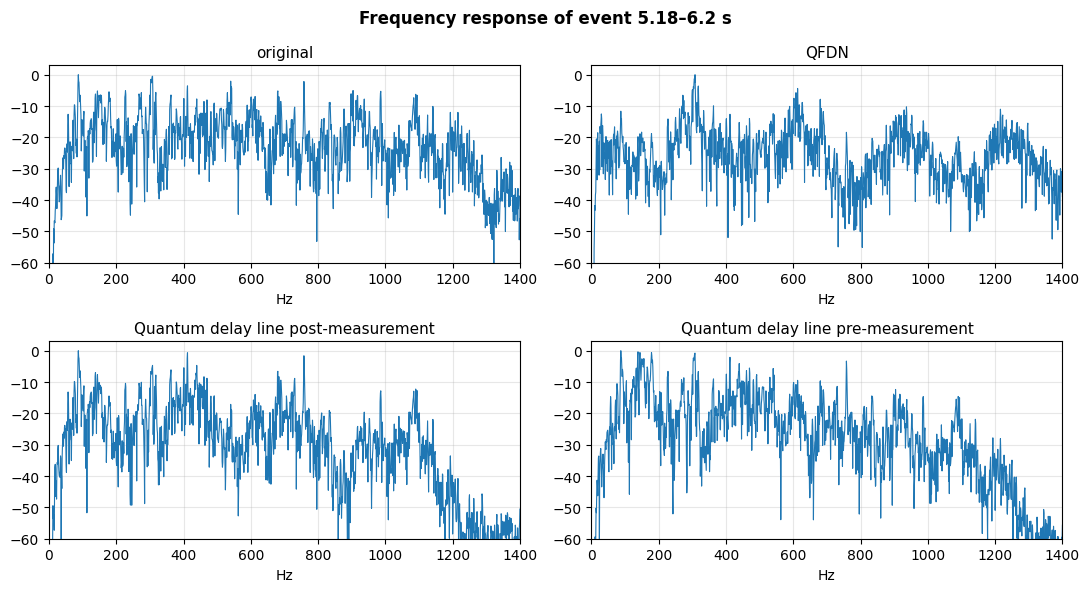

In [10]:
# Spectrum of one isolated audio event: original | Rocchesso (top), single std | single FB (bottom)
import matplotlib.pyplot as plt
RUN='Audio input'; WIN=(5.18, 6.2); FMAX=None      # event window (s)
def _fade(y, fin=40.0, fout=15.0):
    y=np.asarray(y,float).copy(); ni=int(fin*FS/1000); no=int(fout*FS/1000)
    if 0<ni<len(y): y[:ni]*=0.5*(1-np.cos(np.linspace(0,np.pi,ni)))
    if 0<no<len(y): y[-no:]*=0.5*(1+np.cos(np.linspace(0,np.pi,no)))
    return y
def _proc(y): z=_fade(dc_filter(np.asarray(y,float))); return z/(np.max(np.abs(z))+1e-12)*0.9
def _seg(y): return y[int(WIN[0]*FS):int(WIN[1]*FS)]
def _spec(y):
    s=_seg(_proc(y))
    if len(s)<8: return np.array([0.]), np.array([0.])
    Y=np.abs(np.fft.rfft(s*np.hanning(len(s)))); f=np.fft.rfftfreq(len(s),1/FS)
    return f, 20*np.log10(Y/(np.max(Y)+1e-12)+1e-9)
def _inp():
    y=globals().get('audio_in')
    if y is not None: return y
    d,sr=soundfile.read(AUDIO_PATH); d=d[:,0] if d.ndim>1 else d
    return resample(d/(np.max(np.abs(d))+1e-12), int(len(d)*FS/sr))[:int(AUDIO_SEC*FS)]
M=globals().get('QFDN_FB_MATRIX',None); inp=_inp()
qf=run_qfdn_marginal(inp, delay_lengths=QFDN_SINGLE_DELAYS, fCoef=QFDN_FCOEF, matrix=M)['output']
sg_std=RAW_SENSING.get(f'{RUN} / single d={SINGLE_D} std')
sg_fb =RAW_SENSING.get(f'{RUN} / single d={SINGLE_D} fb')
panels=[('original',inp),('QFDN',qf),
        (f'Quantum delay line post-measurement',sg_std),(f'Quantum delay line pre-measurement',sg_fb)]
fmax=FMAX if FMAX else FS/2
fig,ax=plt.subplots(2,2,figsize=(11,6))
fig.suptitle(f'Frequency response of event {WIN[0]}–{WIN[1]} s', fontweight='bold')
for a,(name,y) in zip(ax.flat, panels):
    if y is None: a.set_title(name+' (missing)', fontsize=8); a.axis('off'); continue
    f,mag=_spec(y); a.plot(f,mag,lw=0.8); a.set_xlim(0,fmax); a.set_ylim(-60,3)
    a.set_title(f'{name}', fontsize=11); a.grid(alpha=.3); a.set_xlabel('Hz')
plt.tight_layout(); plt.show()

### Run 7b — Audio input · single, ⚡ optimized unitary (fast=True) vs standard

Same input & sensing params as **Run 7 — Audio input · single** (`trotterize_sensing`,
`delay=SINGLE_D`), run twice for an **actual measured** head-to-head time, an overlaid
**waveform-on-t** equivalence check, and audio of both.

*Requires the params / helper cells above (uses `SINGLE_D`, `FS`, `dc_filter`, `STRETCH_GAIN`, …).*
Reminder: `fast` only wins for **delay ≳ 8**; at delay 5–6 it is at/below the crossover
(equal or a touch slower) but bit-identical.

In [3]:
import time as _time
# rebuild the SAME input as "Run 7 — Audio input · single"
_d, _sr = soundfile.read(AUDIO_PATH)
if _d.ndim > 1: _d = _d[:, 0]
_d = _d / (np.max(np.abs(_d)) + 1e-12)
audio_in7 = resample(_d, int(len(_d)*FS/_sr))[int(START_S*FS):int((START_S+AUDIO_SEC)*FS)]
_t7 = 1.0 / FS

def _sense7(fast):
    t0 = _time.perf_counter()
    o = trotterize_sensing(audio_in7, FS, 0.8*_t7, _t7, phase_scale=PHASE_SCALE,
            delay=SINGLE_D, swap_angle_in=SWAP_IN, swap_angle_out=SWAP_OUT,
            method='sin_phi', fast=fast)['aux_sigma_z']
    return o - np.mean(o), (_time.perf_counter() - t0)

print(f'Run 7 single | delay={SINGLE_D} | {len(audio_in7)/FS:.1f}s @ {FS}Hz  ({len(audio_in7)} samples)')
print('running STANDARD  (fast=False) ...'); std_o, t_std = _sense7(False); print(f'  standard : {t_std:.1f}s')
print('running OPTIMIZED (fast=True ) ...'); fst_o, t_fst = _sense7(True);  print(f'  optimized: {t_fst:.1f}s')
err = np.max(np.abs(std_o - fst_o))
print(f'\n>>> delay={SINGLE_D}:  standard {t_std:.1f}s   vs   optimized {t_fst:.1f}s   speedup = {t_std/t_fst:.2f}x')
print(f'    max |optimized - standard| = {err:.2e}  -> ' + ('IDENTICAL (machine precision)' if err < 1e-9 else 'DIFFERS!'))

# --- waveform on the t axis: standard vs optimized (+ difference) ---
tt = np.arange(len(std_o)) / FS
fig, ax = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
ax[0].plot(tt, std_o, 'tab:blue', lw=0.7, alpha=0.75, label='standard (fast=False)')
ax[0].plot(tt, fst_o, 'r--',      lw=0.6,             label='optimized (fast=True)')
ax[0].set_title(f'Run 7 single sensing readout - waveform  (delay {SINGLE_D})')
ax[0].legend(); ax[0].grid(alpha=0.3); ax[0].axhline(0, color='k', lw=0.3)
ax[1].plot(tt, np.abs(std_o - fst_o), 'k', lw=0.6)
ax[1].set_title(f'|optimized - standard|   (max {err:.1e})'); ax[1].set_xlabel('s'); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

# --- audio (same post-processing as run_and_present's standard read: dc + empirical stretch) ---
for lab, o in [('standard (fast=False)', std_o), ('optimized (fast=True)', fst_o)]:
    y  = apply_gain_clip(fade_edges(dc_filter(o), FADE_MS), STRETCH_GAIN)
    yr = apply_gain_clip(resample(y, int(len(y)*44100/FS)), 1.0)
    print(f'  {lab}   (peak {np.max(np.abs(yr)):.3f})'); display(Audio(yr, rate=44100))

NameError: name 'soundfile' is not defined

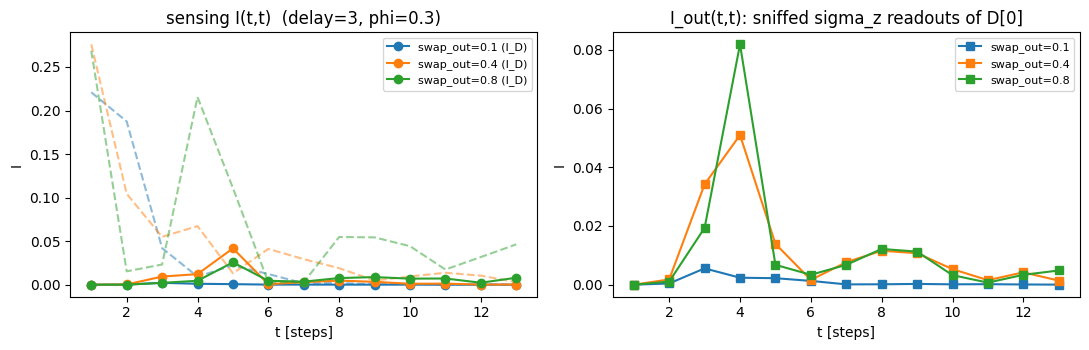

In [4]:
# === DNI Cell 1/2 (QFDN_vs_Sensing notebook) ====================================
# Budini invasiveness I(t,t) for the sensing delay-line loop -- delay = 3,
# constant encoded phase (phi_bar), coupling knob = swap_angle_out.
# left : I_sys aligned (solid, = I_D) vs misaligned (dashed).
#        swap_out = 0 is the Markovian reference: I_D = 0 to machine precision.
# right: I_out with the model's OWN sigma_z readouts of the exiting D[0] as the
#        x and z slots (the quantity trotterize_sensing takes <sz> of, here
#        outcome-resolved), intermediate = aligned system pinch.
import numpy as np, matplotlib.pyplot as plt
from dni_tests import SensingStep, I_sys, I_out

DELAY, TS, PHI = 3, np.arange(1, 14), 0.3
SOUTS = (0.1, 0.4, 0.8)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for so in SOUTS:
    m = SensingStep(delay=DELAY, phi_bar=PHI, swap_angle_out=so)
    ax[0].plot(TS, [I_sys(m, n) for n in TS], 'o-', label=f'swap_out={so} (I_D)')
    ax[0].plot(TS, [I_sys(m, n, aligned=False) for n in TS], '--',
               color=ax[0].lines[-1].get_color(), alpha=.5)
    ax[1].plot(TS, [I_out(m, 0, n, 2 * n) for n in TS], 's-', label=f'swap_out={so}')
ax[0].set_title(f'sensing I(t,t)  (delay={DELAY}, phi={PHI})'); ax[0].legend(fontsize=8)
ax[1].set_title('I_out(t,t): sniffed sigma_z readouts of D[0]'); ax[1].legend(fontsize=8)
for a in ax: a.set_xlabel('t [steps]'); a.set_ylabel('I')
plt.tight_layout(); plt.show()
# Reverb variant: SensingStep(..., exp_feed_back=True, feedback_swap_angle=...)


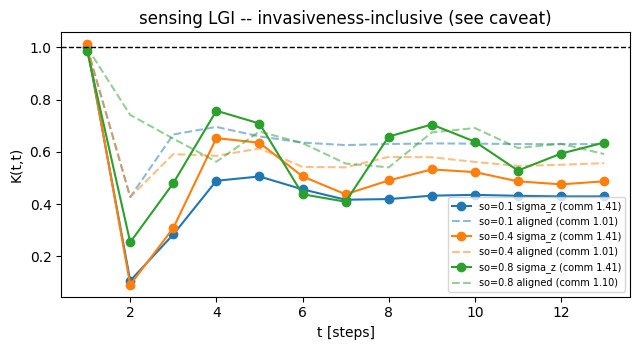

In [5]:
# === DNI Cell 2/2 (QFDN_vs_Sensing notebook) ====================================
# LGI K(t,t) for the sensing loop. Two observable choices:
#   sigma_z everywhere (the model's native readout axis -- your request), and
#   'aligned' (eigenbasis of the unconditioned state at each time).
# CAVEAT printed in the legend: the sensing dynamics moves conditional states, so
# ||[rho_pre, O]|| = O(1) for BOTH choices -- any K>1 here would be standard,
# invasiveness-inclusive LGI, NOT attributable to memory (Budini Sec. IV.D).
# The memory witness for sensing is I_D from Cell 1, which aligns per branch.
import numpy as np, matplotlib.pyplot as plt
from dni_tests import SensingStep, K_lgi

DELAY, TS, PHI = 3, np.arange(1, 14), 0.3
fig, ax = plt.subplots(1, 1, figsize=(6.5, 3.6))
for so in (0.1, 0.4, 0.8):
    m = SensingStep(delay=DELAY, phi_bar=PHI, swap_angle_out=so)
    Kz = [K_lgi(m, n, basis='z') for n in TS]
    Ka = [K_lgi(m, n, basis='aligned') for n in TS]
    ax.plot(TS, [k for k, _ in Kz], 'o-',
            label=f'so={so} sigma_z (comm {max(c for _, c in Kz):.2f})')
    ax.plot(TS, [k for k, _ in Ka], '--', color=ax.lines[-1].get_color(), alpha=.5,
            label=f'so={so} aligned (comm {max(c for _, c in Ka):.2f})')
ax.axhline(1.0, ls='--', c='k', lw=1)
ax.set_xlabel('t [steps]'); ax.set_ylabel('K(t,t)')
ax.set_title('sensing LGI -- invasiveness-inclusive (see caveat)')
ax.legend(fontsize=7); plt.tight_layout(); plt.show()
